# Librerías

In [2]:
import os
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from time import time

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split, cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# Lectura de datos y procesamiento

In [3]:
# @title Lectura de datos
ruta_dataset = r"https://raw.githubusercontent.com/Manumora117/AI-Master-s-Projects-and-Exercises/refs/heads/main/Aprendizaje%20Supervisado/Proyecto%20Final%20en%20equipo%20-%20Datos%20Estructurados%20(Clasificaci%C3%B3n)/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(ruta_dataset)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
# @title Limpiar Datos
df.drop("customerID", axis=1, inplace=True, errors='ignore')
X = df.drop("Churn", axis=1)
y = df["Churn"]
y = y.map({"Yes": 1, "No": 0})

cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(exclude=["object"]).columns

# 1. Definir el preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False, drop='first'), cat_cols)])

# 2. Pedir que el resultado se mantenga como DataFrame de Pandas
preprocessor.set_output(transform="pandas")

# 3. Aplicar todas las transformaciones a la vez
X = preprocessor.fit_transform(X)

y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [5]:
# @title Procesamiento de Datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69, stratify=df['Churn'])
print(f"Muestra antes de SMOTE: {len(X_train)}")

# Aplicar SMOTE
sm = SMOTE(random_state=69)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(f"Muestra después de SMOTE: {len(X_train_sm)}")

# Calculas los pesos basados en tus datos de entrenamiento
pesos = compute_sample_weight(class_weight='balanced', y=y_train)

Muestra antes de SMOTE: 5634
Muestra después de SMOTE: 8278


# Grid Search

============================== Regresión Logística ==============================
CV ROC-AUC (5 folds): 0.9115 (+/- 0.0140)
Tiempo de entrenamiento y predicción: 0.55 segundos
Accuracy: 0.7800
AUC Score: 0.8437
Matriz de Confusión:
 [[822 213]
 [ 97 277]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.89      0.79      0.84      1035
           1       0.57      0.74      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.78      0.79      1409


============================== KNN ==============================
CV ROC-AUC (5 folds): 0.8562 (+/- 0.0277)
Tiempo de entrenamiento y predicción: 1.17 segundos
Accuracy: 0.6402
AUC Score: 0.7641
Matriz de Confusión:
 [[587 448]
 [ 59 315]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.91      0.57      0.70      1035
           1 

g:\Mi unidad\CUATRIMESTRES\.venv_PC\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
g:\Mi unidad\CUATRIMESTRES\.venv_PC\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


CV ROC-AUC (5 folds): 0.9785 (+/- 0.0139)
Tiempo de entrenamiento y predicción: 148.97 segundos
Accuracy: 0.7800
AUC Score: 0.8028
Matriz de Confusión:
 [[906 129]
 [181 193]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.83      0.88      0.85      1035
           1       0.60      0.52      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.70      1409
weighted avg       0.77      0.78      0.77      1409


============================== Random Forest ==============================
CV ROC-AUC (5 folds): 0.9623 (+/- 0.0308)
Tiempo de entrenamiento y predicción: 14.04 segundos
Accuracy: 0.7977
AUC Score: 0.8295
Matriz de Confusión:
 [[920 115]
 [170 204]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy               

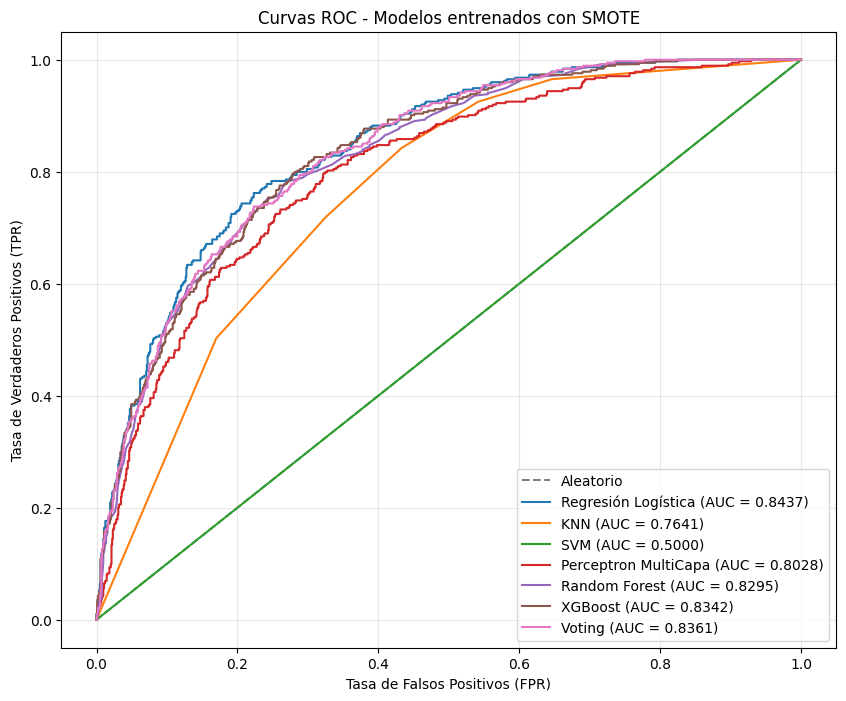

============================== XGBoost ==============================
Accuracy: 0.7934705464868701
[[901 134]
 [157 217]]
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1035
           1       0.62      0.58      0.60       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409

============================== Voting ==============================
Accuracy: 0.7714691270404542
[[828 207]
 [115 259]]
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1035
           1       0.56      0.69      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409



In [ ]:
# @title Algoritmos con SMOTE
# Función auxiliar para evaluar, imprimir métricas y graficar ROC
def evaluar_modelo(modelo, nombre, X_tr, y_tr, X_te, y_te):
    print("="*30, nombre, "="*30)
    
    # Validación Cruzada (ROC AUC)
    cv_scores = cross_val_score(modelo, X_tr, y_tr, cv=5, scoring='roc_auc')
    print(f"CV ROC-AUC (5 folds): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    
    # Entrenamiento y Predicción
    start_time = time()
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    end_time = time()
    print(f"Tiempo de entrenamiento y predicción: {end_time - start_time:.2f} segundos")
    
    # Probabilidades para ROC/AUC
    y_prob = modelo.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, y_prob)
    
    print(f"Accuracy: {accuracy_score(y_te, y_pred):.4f}")
    print(f"AUC Score: {auc:.4f}")
    print("Matriz de Confusión:\n", confusion_matrix(y_te, y_pred))
    print("Reporte de Clasificación:\n", classification_report(y_te, y_pred))
    print("=" * 100, "\n")
    
    # Calcular datos para la curva ROC
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.4f})")

# Configurar el gráfico general para SMOTE
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatorio')

# 1. Regresión Logística
lr = LogisticRegression(solver='liblinear', random_state=69)
evaluar_modelo(lr, "Regresión Logística", X_train_sm, y_train_sm, X_test, y_test)

# 2. KNN
knn = KNeighborsClassifier(metric="minkowski")
evaluar_modelo(knn, "KNN", X_train_sm, y_train_sm, X_test, y_test)

# 3. SVM (Requiere probability=True para ROC)
svm = SVC(kernel="poly", C=0.1, gamma=0.001, probability=True, random_state=69) # Primer corrida, sin buenos resultados
evaluar_modelo(svm, "SVM", X_train_sm, y_train_sm, X_test, y_test)

# 4. Multilayer Perceptron
mlp = MLPClassifier(random_state=69)
evaluar_modelo(mlp, "Perceptron MultiCapa", X_train_sm, y_train_sm, X_test, y_test)

# 5. Random Forest
rf = RandomForestClassifier(random_state=69)
evaluar_modelo(rf, "Random Forest", X_train_sm, y_train_sm, X_test, y_test)

# 6. XGBoost
xgb = XGBClassifier(random_state=69)
evaluar_modelo(xgb, "XGBoost", X_train_sm, y_train_sm, X_test, y_test)

# 7. Voting (Requiere voting='soft' para ROC)
voting = VotingClassifier(
    estimators=[('lr', lr), ('knn', knn), ('svm', svm), ('rf', rf), ('xgb', xgb)],
    voting='soft'
)
evaluar_modelo(voting, "Voting", X_train_sm, y_train_sm, X_test, y_test)

# Mostrar Gráfico ROC final
plt.title("Curvas ROC - Modelos entrenados con SMOTE")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()
# XGBoost
print("="*30, "XGBoost", "="*30)
xgb = XGBClassifier(random_state=69)
xgb.fit(X_train_sm, y_train_sm)
y_pred_xgb = xgb.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb)}")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("=" * 100)

# Voting
print("="*30, "Voting", "="*30)
voting = VotingClassifier(
    estimators=[('lr', lr), ('knn', knn), ('svm', svm), ('rf', rf), ('xgb', xgb)],
    voting='soft')
"""El voto "duro" (hard) solo devuelve la clase final, mientras que el voto "suave" (soft) devuelve el promedio de las probabilidades 
de los modelos internos, permitiendo calcular el AUC y la curva ROC."""
voting.fit(X_train_sm, y_train_sm)
y_pred_voting = voting.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_voting)}")
print(confusion_matrix(y_test, y_pred_voting))
print(classification_report(y_test, y_pred_voting))
print("=" * 100)
# Tiempo Total ---> 143m 2.0s

============================== Regresión Logística ==============================
CV ROC-AUC (5 folds): 0.8435 (+/- 0.0071)
Tiempo de entrenamiento y predicción: 0.35 segundos
Accuracy: 0.7665
AUC Score: 0.8452
Matriz de Confusión:
 [[797 238]
 [ 91 283]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.54      0.76      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409


============================== KNN ==============================
KNN no soporta class_weight, omitiendo para la gráfica ROC.

============================== SVM ==============================
CV ROC-AUC (5 folds): 0.8019 (+/- 0.0051)
Tiempo de entrenamiento y predicción: 360.89 segundos
Accuracy: 0.2654
AUC Score: 0.1926
Matriz de Confusión:
 [[   0 1035]
 [   0  374]]
Reporte de Clasi

g:\Mi unidad\CUATRIMESTRES\.venv_PC\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
g:\Mi unidad\CUATRIMESTRES\.venv_PC\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
g:\Mi unidad\CUATRIMESTRES\.venv_PC\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

CV ROC-AUC (5 folds): 0.8279 (+/- 0.0045)
Tiempo de entrenamiento y predicción: 10.52 segundos
Accuracy: 0.7991
AUC Score: 0.8343
Matriz de Confusión:
 [[933 102]
 [181 193]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


============================== XGBoost ==============================
CV ROC-AUC (5 folds): 0.8113 (+/- 0.0066)
Accuracy: 0.7502
AUC Score: 0.8292
Matriz de Confusión:
 [[800 235]
 [117 257]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.87      0.77      0.82      1035
           1       0.52      0.69      0.59       374

    accuracy                           0.75      1409
   macro avg       0.70      0.73

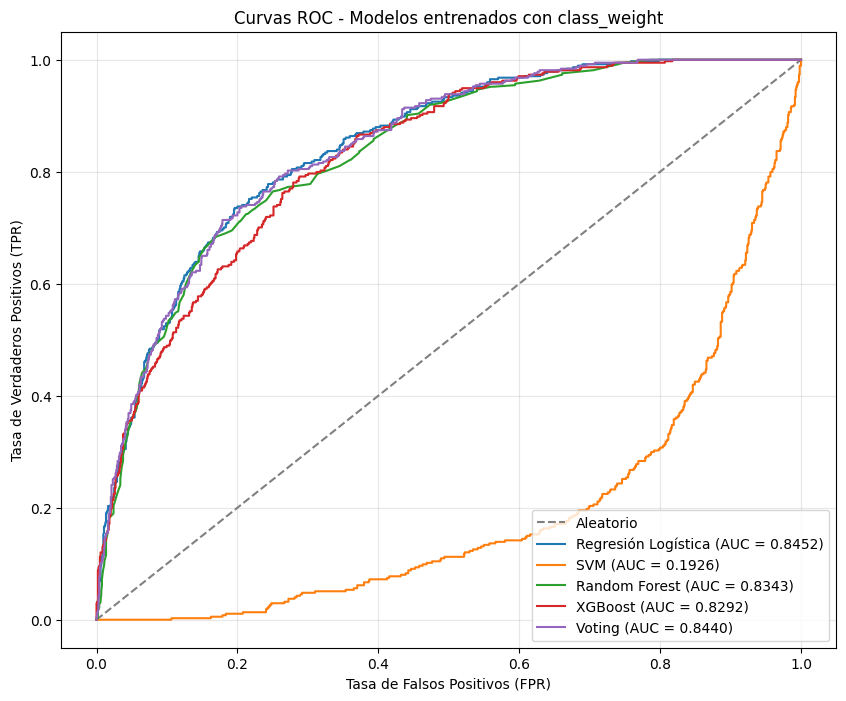

In [ ]:
# @title Algoritmos con class_weight
# Mismo gráfico, ahora para class_weight
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatorio')

# 1. Regresión Logística
lr_cw = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=69)
evaluar_modelo(lr_cw, "Regresión Logística", X_train, y_train, X_test, y_test)

print("="*30, "KNN", "="*30)
print("KNN no soporta class_weight, omitiendo para la gráfica ROC.\n")

# 2. SVM
svm_cw = SVC(class_weight='balanced', kernel="poly", C=0.1, gamma=0.001, probability=True, random_state=69)
evaluar_modelo(svm_cw, "SVM", X_train, y_train, X_test, y_test)

print("="*30, "Perceptron MultiCapa", "="*30)
print("MLP no soporta class_weight, omitiendo para la gráfica ROC.\n")

# 3. Random Forest
rf_cw = RandomForestClassifier(class_weight='balanced', random_state=69)
evaluar_modelo(rf_cw, "Random Forest", X_train, y_train, X_test, y_test)

# 4. XGBoost (Requiere sample_weight al hacer fit)
print("="*30, "XGBoost", "="*30)
xgb_cw = XGBClassifier(random_state=69)
# CV no puede usar sample_weight directamente así de fácil, por lo que calculamos normal
cv_scores = cross_val_score(xgb_cw, X_train, y_train, cv=5, scoring='roc_auc')
print(f"CV ROC-AUC (5 folds): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
# Entrenamiento con pesos
xgb_cw.fit(X_train, y_train, sample_weight=pesos)
y_pred_xgb = xgb_cw.predict(X_test)
y_prob_xgb = xgb_cw.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"AUC Score: {auc_xgb:.4f}")
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_xgb))
print("Reporte de Clasificación:\n", classification_report(y_test, y_pred_xgb))
print("=" * 100, "\n")
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.4f})")

# 5. Voting
voting_cw = VotingClassifier(
    estimators=[('lr', lr_cw), ('svm', svm_cw), ('rf', rf_cw), ('xgb', xgb_cw)],
    voting='soft'
)
# Nota: Voting no pasará sample_weight a XGBoost automáticamente en .fit()
evaluar_modelo(voting_cw, "Voting", X_train, y_train, X_test, y_test)

# Mostrar Gráfico ROC final
plt.title("Curvas ROC - Modelos entrenados con class_weight")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Tiempo Total ---> 53m 12.6s

# Segunda Corrida

============================== SVM ==============================
CV ROC-AUC (5 folds): 0.8452 (+/- 0.0081)
Tiempo de entrenamiento y predicción: 773.94 segundos
Accuracy: 0.7282
AUC Score: 0.8393
Matriz de Confusión:
 [[722 313]
 [ 70 304]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.91      0.70      0.79      1035
           1       0.49      0.81      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.80      0.73      0.74      1409




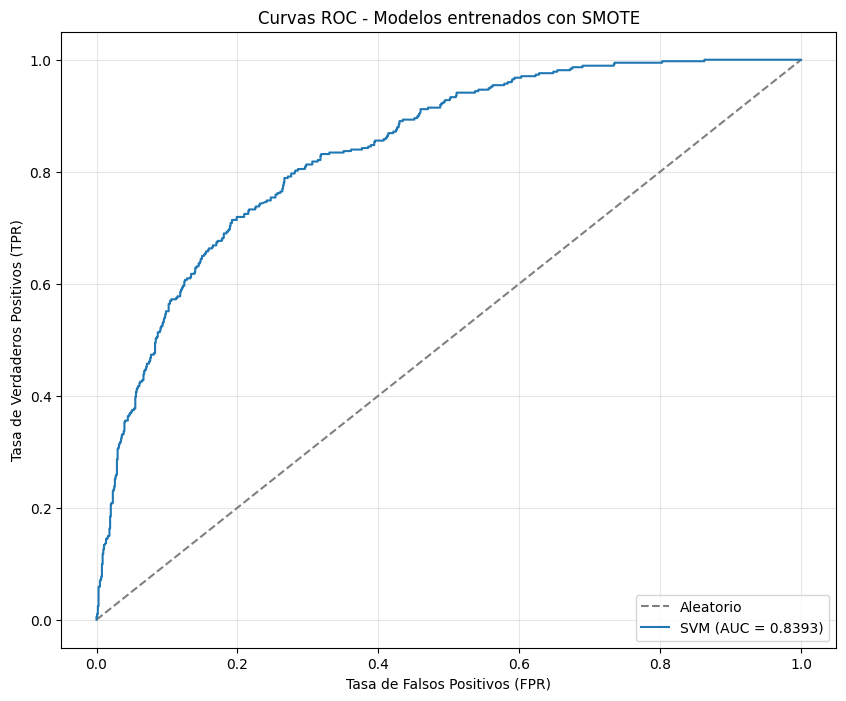

============================== SVM ==============================
CV ROC-AUC (5 folds): 0.8320 (+/- 0.0071)
Tiempo de entrenamiento y predicción: 388.21 segundos
Accuracy: 0.6984
AUC Score: 0.8377
Matriz de Confusión:
 [[668 367]
 [ 58 316]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.92      0.65      0.76      1035
           1       0.46      0.84      0.60       374

    accuracy                           0.70      1409
   macro avg       0.69      0.75      0.68      1409
weighted avg       0.80      0.70      0.72      1409




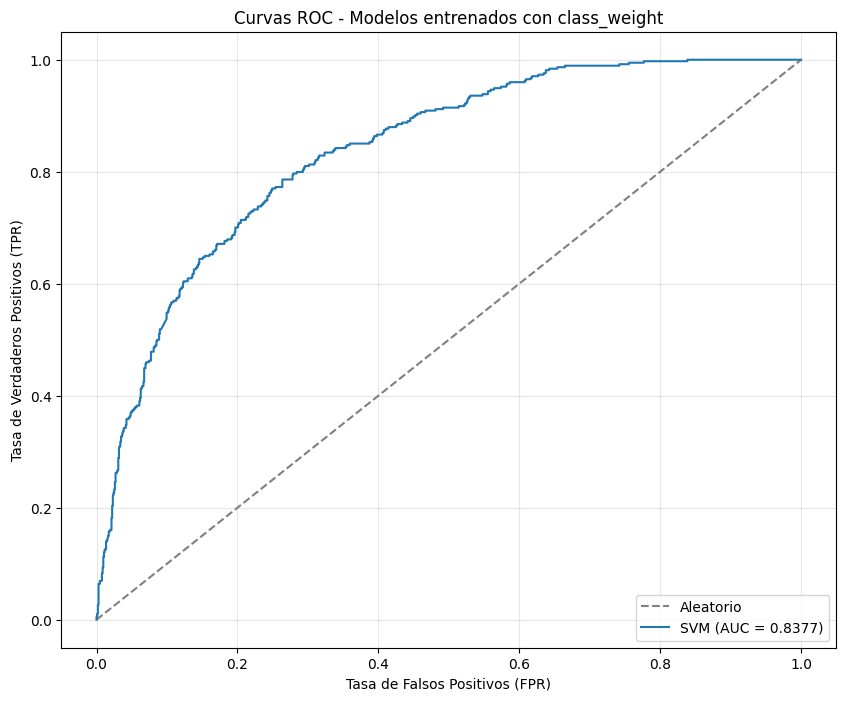

In [ ]:
# Función auxiliar para evaluar, imprimir métricas y graficar ROC
def evaluar_modelo(modelo, nombre, X_tr, y_tr, X_te, y_te):
    print("="*30, nombre, "="*30)
    
    # Validación Cruzada (ROC AUC)
    cv_scores = cross_val_score(modelo, X_tr, y_tr, cv=5, scoring='roc_auc')
    print(f"CV ROC-AUC (5 folds): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    
    # Entrenamiento y Predicción
    start_time = time()
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    end_time = time()
    print(f"Tiempo de entrenamiento y predicción: {end_time - start_time:.2f} segundos")
    
    # Probabilidades para ROC/AUC
    y_prob = modelo.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, y_prob)
    
    print(f"Accuracy: {accuracy_score(y_te, y_pred):.4f}")
    print(f"AUC Score: {auc:.4f}")
    print("Matriz de Confusión:\n", confusion_matrix(y_te, y_pred))
    print("Reporte de Clasificación:\n", classification_report(y_te, y_pred))
    print("=" * 100, "\n")
    
    # Calcular datos para la curva ROC
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.4f})")

# Configurar el gráfico general para SMOTE
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatorio')

svm = SVC(kernel="rbf", C=0.1, gamma=0.001, probability=True, random_state=69)
evaluar_modelo(svm, "SVM", X_train_sm, y_train_sm, X_test, y_test)

# Mostrar Gráfico ROC final
plt.title("Curvas ROC - Modelos entrenados con SMOTE")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

#================= Class_weight =================

# Mismo gráfico, ahora para class_weight
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatorio')

# 2. SVM
svm_cw = SVC(class_weight='balanced', kernel="rbf", C=0.1, gamma=0.001, probability=True, random_state=69)
evaluar_modelo(svm_cw, "SVM", X_train, y_train, X_test, y_test)

# Mostrar Gráfico ROC final
plt.title("Curvas ROC - Modelos entrenados con class_weight")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()
# Tiempo Total ---> 85m 24.9s